# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [111]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/1. IT study/Data Loves Academy/Data Analyst/11. Модуль 11/data/yulu_rental.csv')

In [113]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [114]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [115]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [116]:
# Розмір набору даних
print(df.shape)

(10886, 19)


У нас насправді 20 полів, але Pandas показує 19 columns, бо одна з них — datetime — використовується як індекс (index), а не як колонка.

In [117]:
print(df.columns)

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'date', 'day',
       'week', 'weekday_num', 'weekday', 'year', 'month', 'hour'],
      dtype='object')


In [118]:
# Перші рядки
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [119]:
# Інформація про стовпці
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       10886 non-null  int64  
 1   holiday      10886 non-null  int64  
 2   workingday   10886 non-null  int64  
 3   weather      10886 non-null  int64  
 4   temp         10886 non-null  float64
 5   atemp        10886 non-null  float64
 6   humidity     10886 non-null  int64  
 7   windspeed    10886 non-null  float64
 8   casual       10886 non-null  int64  
 9   registered   10886 non-null  int64  
 10  count        10886 non-null  int64  
 11  date         10886 non-null  object 
 12  day          10886 non-null  int32  
 13  week         10886 non-null  UInt32 
 14  weekday_num  10886 non-null  int32  
 15  weekday      10886 non-null  object 
 16  year         10886 non-null  int32  
 17  month        10886 non-null  int32  
 18  hour       

In [120]:
print('Кількість рядків:', df.shape[0])
print('Кількість колонок:', df.shape[1])

Кількість рядків: 10886
Кількість колонок: 19


Розмір набору даних становить `10 886 рядків` та `19 колонок`. Кожен рядок містить інформацію про оренду велосипедів за одну годину. Додатково datetime використовується як індекс DataFrame, тому не враховується у `df.shape[1]` як окрема колонка.

Якщо окрім розміру набору даних рахувати ще розмір файлу, тоді:

In [121]:
import os

file_path = '/content/drive/MyDrive/1. IT study/Data Loves Academy/Data Analyst/11. Модуль 11/data/yulu_rental.csv'

file_size = os.path.getsize(file_path)

print(f'Розмір файлу: {file_size / 1024:.2f} KB')
print(f'Розмір файлу: {file_size / (1024**2):.2f} MB')

Розмір файлу: 633.16 KB
Розмір файлу: 0.62 MB


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [122]:
daily_rentals = df.groupby('date', as_index=False)['count'].sum()

daily_rentals

,date,count
0,2011-01-01,985
1,2011-01-02,801
2,2011-01-03,1349
3,2011-01-04,1562
4,2011-01-05,1600
...,...,...
451,2012-12-15,5047
452,2012-12-16,3786
453,2012-12-17,4585
454,2012-12-18,5557


In [123]:
import pandas as pd
import matplotlib.pyplot as plt

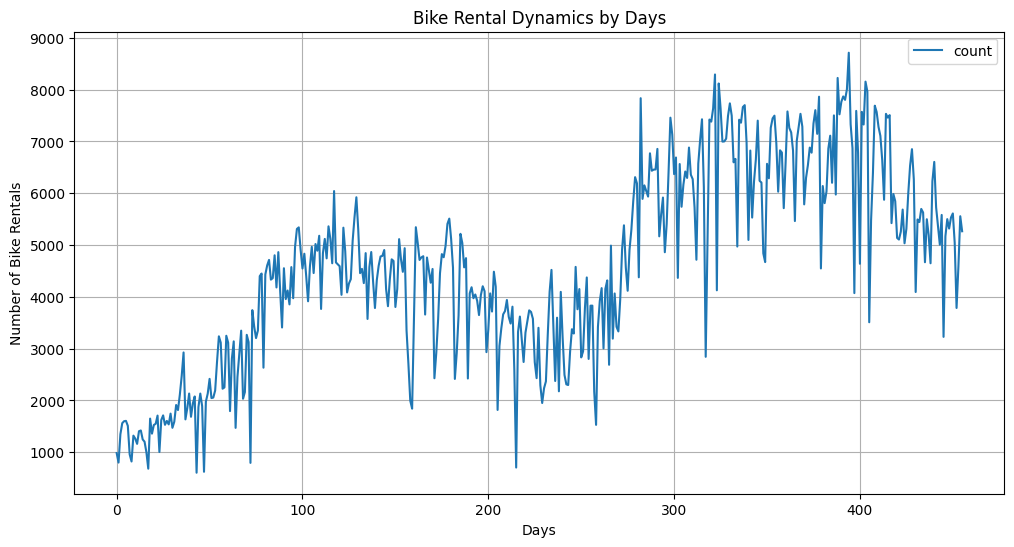

In [124]:
daily_rentals.plot(
    figsize=(12, 6),
    title='Bike Rental Dynamics by Days',
    grid=True
)

plt.xlabel('Days')
plt.ylabel('Number of Bike Rentals')
plt.show()

З ресемплінгом по днях:

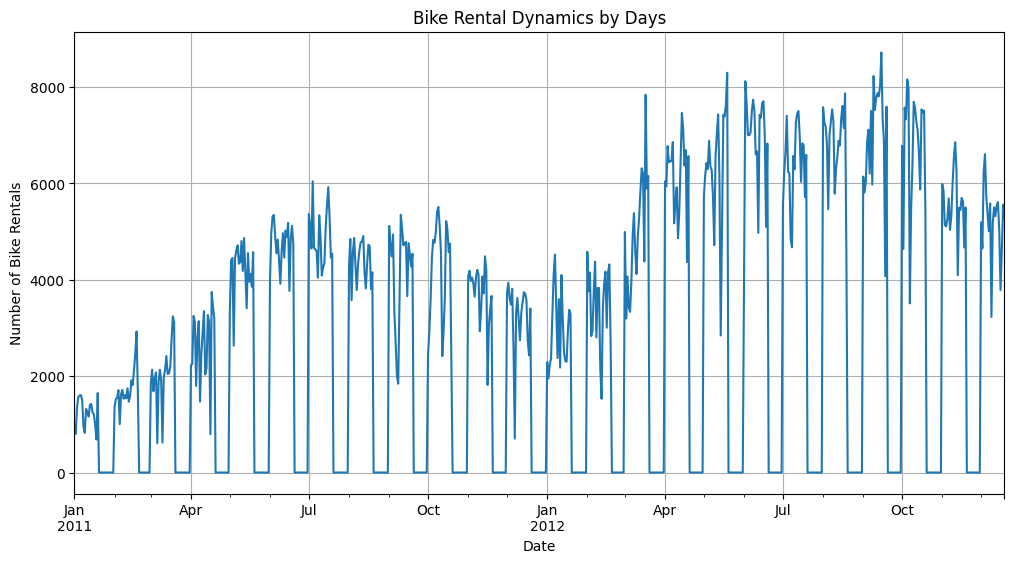

In [125]:
daily_rentals = df['count'].resample('D').sum()

daily_rentals.plot(
    figsize=(12, 6),
    title='Bike Rental Dynamics by Days',
    grid=True
)

plt.xlabel('Date')
plt.ylabel('Number of Bike Rentals')
plt.show()

In [126]:
# дивимось всі дати, коли загальна кількість оренд за день (count) була 0
daily_rentals[daily_rentals == 0]

,count
datetime,
2011-01-20,0
2011-01-21,0
2011-01-22,0
2011-01-23,0
2011-01-24,0
...,...
2012-11-26,0
2012-11-27,0
2012-11-28,0


In [127]:
daily_rentals.head(25)

,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
2011-01-06,1606
2011-01-07,1510
2011-01-08,959
2011-01-09,822


In [128]:
print(daily_rentals.min())
print(daily_rentals[daily_rentals == 0].count())

0
263


In [129]:
daily_rentals[daily_rentals == 0].count()

np.int64(263)

Нам потрібно знати, де взялися ці нулі - ци вони є в початковому датасеті і відображають по реальних 0 оренд в конкретні дні чи вони появилися в результаті ресемплінгу по днях у `daily_rentals`.

Заломи на графіку можуть бути спричинені пропущеними датами в початкових даних. Під час використання `resample('D').sum()` для дат, за які немає жодного запису, утворюється значення 0. Оскільки в початковому стовпці `count` мінімальне значення дорівнює 1, а не 0, то ці нулі не є реальною кількістю оренд, а виникають через відсутність даних. Для усунення таких заломів можна замінити ці нульові значення на NaN, щоб не з'єднувати відсутні дані лінією.

In [130]:
daily_rentals.describe()

,count
count,719.000000
mean,2900.522949
std,2659.328686
min,0.000000
25%,0.000000
50%,2935.000000
75%,5027.500000
max,8714.000000


In [131]:
df['count'].describe()

,count
count,10886.000000
mean,191.574132
std,181.144454
min,1.000000
25%,42.000000
50%,145.000000
75%,284.000000
max,977.000000


Бачимо, що в початкуомову датасеті 0 немає в жодному з рядків, мінімальне значення є 1.

In [132]:
# дивимось у які дати відсутні дані

all_days = pd.date_range(
    start=df.index.min().normalize(),
    end=df.index.max().normalize(),
    freq='D'
)

missing_days = all_days.difference(
    df.index.normalize().unique()
)

missing_days

DatetimeIndex(['2011-01-20', '2011-01-21', '2011-01-22', '2011-01-23',
               '2011-01-24', '2011-01-25', '2011-01-26', '2011-01-27',
               '2011-01-28', '2011-01-29',
               ...
               '2012-11-21', '2012-11-22', '2012-11-23', '2012-11-24',
               '2012-11-25', '2012-11-26', '2012-11-27', '2012-11-28',
               '2012-11-29', '2012-11-30'],
              dtype='datetime64[ns]', length=263, freq=None)

In [133]:
df['count'].resample('D').sum().loc['2011-01-18':'2011-01-30']

,count
datetime,
2011-01-18,683
2011-01-19,1650
2011-01-20,0
2011-01-21,0
2011-01-22,0
2011-01-23,0
2011-01-24,0
2011-01-25,0
2011-01-26,0


In [134]:
# дивимось останні години 2011-01-19 і далі 2011-01-20 і т д - бачимо, що з 2011-01-20 із 00:00 год дані дійсно відсутні
df.loc['2011-01-19':'2011-01-30'].iloc[21:50]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-19 22:00:00,1,0,1,1,12.3,15.150,52,11.0014,6,53,59,2011-01-19,19,3,2,Wednesday,2011,1,22
2011-01-19 23:00:00,1,0,1,1,12.3,13.635,52,31.0009,1,27,28,2011-01-19,19,3,2,Wednesday,2011,1,23


Замінюємо нульові значення на `NaN` - це важливо, якщо нулі виникли тому, що в датасеті немає записів за цей день, бо `NaN` при обчисленні `mean()` ігнорується.

In [135]:
import numpy as np

# замінюємо нульові значення на NaN
daily_rentals = daily_rentals.replace(0, np.nan)

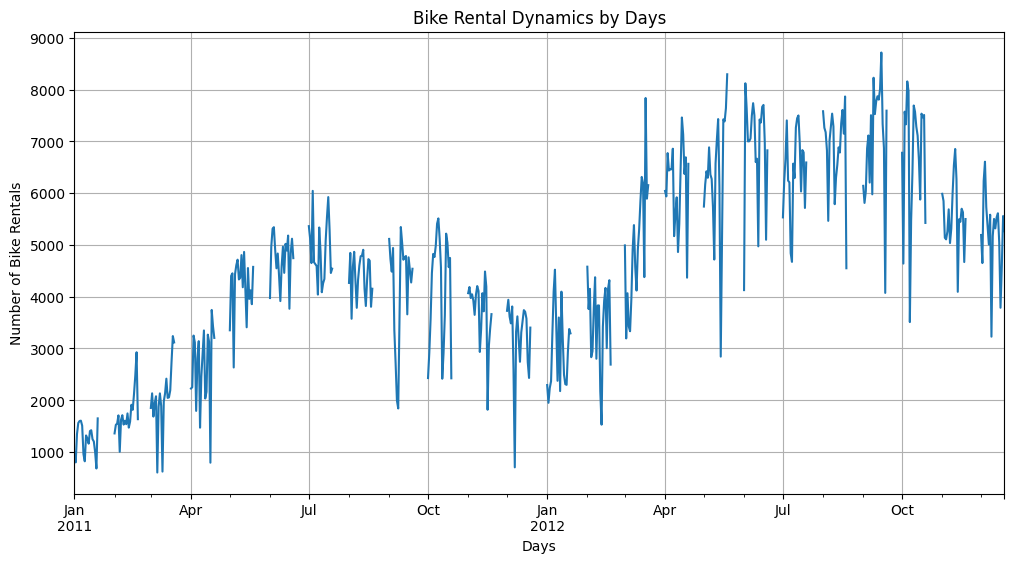

In [136]:
daily_rentals.plot(
    figsize=(12, 6),
    title='Bike Rental Dynamics by Days',
    grid=True
)

plt.xlabel('Days')
plt.ylabel('Number of Bike Rentals')
plt.show()

Аналізуючи графік «Bike Rental Dynamics by Days», можна виділити наступні закономірності:

 **1. Загальні тенденції**

* Зростання попиту з часом: Чітко простежується загальна тенденція до збільшення кількості орендованих велосипедів у 2012 році порівняно з 2011 роком.
* Базова лінія мінімумів і максимумів у 2012 році змістилася вище.

**2. Сезонні коливання**
* Яскраво виражена сезонність: Попит безпосередньо залежить від пори року.
У теплі місяці (весна - літо) показники сягають піків (до 7000–9000 оренд).
У холодні місяці (пізня осінь - зима, зокрема навколо січня) кількість оренд падає.

**3. Аномалії та різкі коливання**
* Різкі спади (провали до мінімумів): На графіку видно різкі «провали» вниз навіть у розпал сезону або в загальному тренді.
Ймовірні причини: Погані погодні умови (раптові дощі, негода, штормові попередження, сильне похолодання), святкові дні зі зміною трафіку або технічні проблеми у роботі сервісу прокату.
* Пікові значення: Найвищі показники спостерігаються влітку та восени 2012 року (наближаючись до позначки 9000).
Ймовірні причини: Сприятлива сонячна погода, вихідні чи святкові дні з високою туристичною активністю, або ж зростання популярності самого сервісу (маркетингові кампанії, розширення мережі станцій прокату).


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

Якщо ми рахуємо середнє значення оренд велосипедів по кварталах разом за 2011 та 2012 роки:

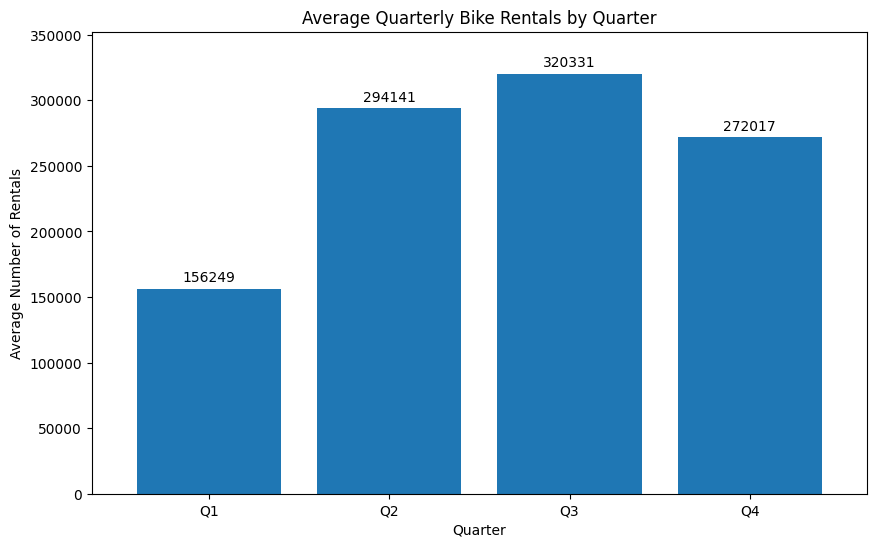

In [137]:
# рахуємо окремо кожен квартал кожного року загальну кількість:

quarterly_rentals = df['count'].resample('QE').sum()

# групуємо однакові квартали різних років і рахуємо середнє:

seasonal_rentals = quarterly_rentals.groupby(
    quarterly_rentals.index.quarter
).mean()

seasonal_rentals.index = ['Q1', 'Q2', 'Q3', 'Q4']

ax = seasonal_rentals.plot(
    kind='bar',
    figsize=(10, 6),
    width=0.8,
    title='Average Quarterly Bike Rentals by Quarter'
)

plt.xlabel('Quarter')
plt.ylabel('Average Number of Rentals')
plt.xticks(rotation=0)

ax.bar_label(            # ставимо значення над бінами
    ax.containers[0],
    fmt='%.0f',
    padding=3
)

plt.ylim(top=seasonal_rentals.max() * 1.1)     # робимо більший відступ від найвищого біна до стелі

plt.show()

In [138]:
# всього орендованих автомобілів за 2 роки (2011 та 2012)

df['count'].sum()

np.int64(2085476)

1. Найбільша середня кількість оренди: у Q3 (третій квартал) із показником 320 331.

2. Пояснення сезонної закономірності: Найвищі показники у Q3 (липень - вересень) та Q2 (квітень - червень) зумовлені теплими погодними умовами, довшим світловим днем та періодом відпусток, коли люди частіше обирають активний відпочинок на свіжому повітрі та пересування на велосипедах. Натомість у Q1 (січень - березень) спостерігається найнижчий попит (156 249 оренд).

3. Різниця між найпопулярнішим і найменш популярним кварталами: $$\frac{320 331}{156 249} \approx 2.05$$
Бачимр, що показники відрізняються приблизно у 2 рази.

Якщо ж ми рахуємо середню ПОДЕННУ кількість оренд велосипедів у кожному з кварталів за 2011-2012 роки, тоді йдемо наступним шляхом:

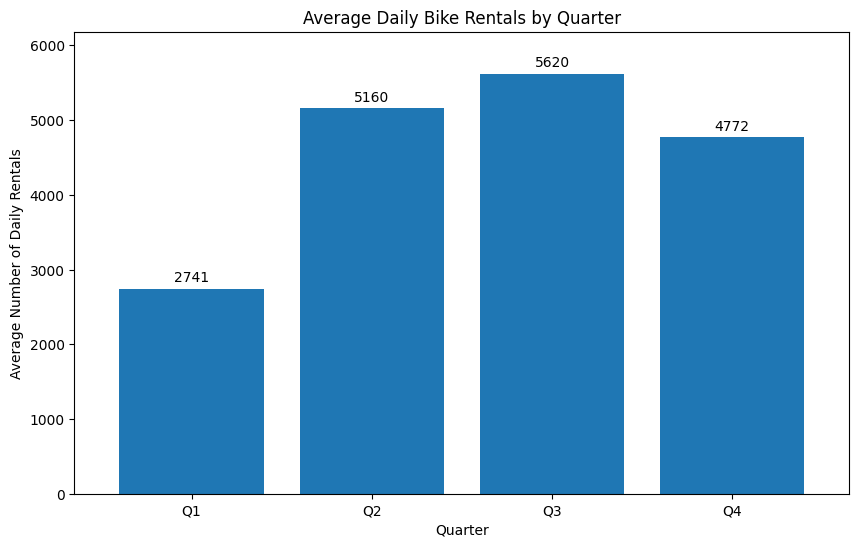

In [139]:
# рахуємо загальну кількість оренд за кожен день
daily_rentals = df['count'].resample('D').sum()

# замінюємо нульові значення на NaN - Це важливо, якщо нулі виникли тому (а це так, ми вище це визначили), що в датасеті немає записів за цей день. NaN при обчисленні mean() ігнорується
daily_rentals = daily_rentals.replace(0, np.nan)

# рахуємо середню ДЕННУ кількість оренд для кожного кварталу - беруться всі денні значення та групуються за кварталом
seasonal_rentals = daily_rentals.groupby(
    daily_rentals.index.quarter
).mean()

seasonal_rentals.index = ['Q1', 'Q2', 'Q3', 'Q4']

ax = seasonal_rentals.plot(
    kind='bar',
    figsize=(10, 6),
    width=0.8,
    title='Average Daily Bike Rentals by Quarter'
)

plt.xlabel('Quarter')
plt.ylabel('Average Number of Daily Rentals')
plt.xticks(rotation=0)

ax.bar_label(                 # ставимо значення над бінами
    ax.containers[0],
    fmt='%.0f',
    padding=3
)

plt.ylim(top=seasonal_rentals.max() * 1.1)     # робимо більший відступ від найвищого біна до стелі

plt.show()

Тут

```
Q1 → усі дні січня + лютого + березня за 2011 і 2012
Q2 → усі дні квітня + травня + червня за 2011 і 2012
Q3 → усі дні липня + серпня + вересня за 2011 і 2012
Q4 → усі дні жовтня + листопада + грудня за 2011 і 2012
```



## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


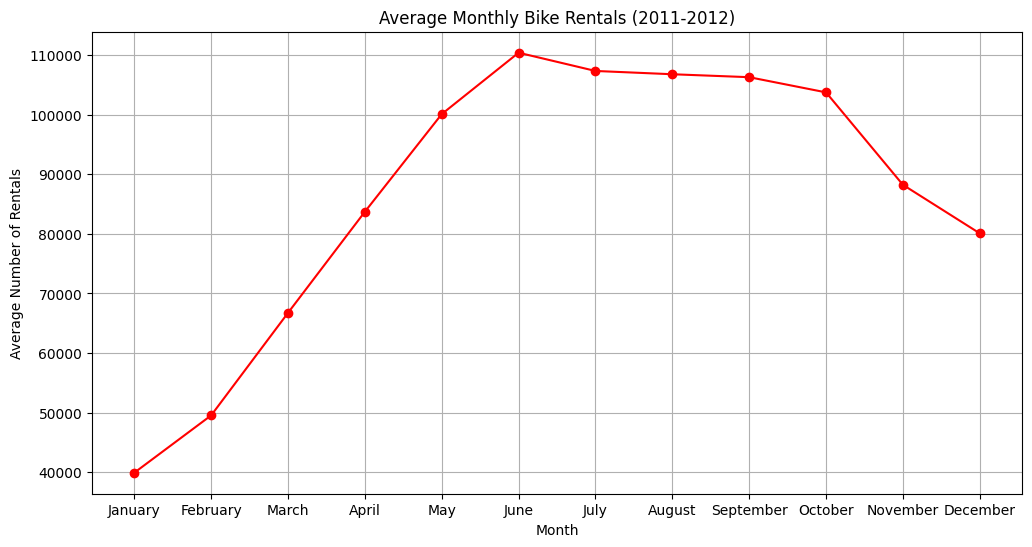

In [140]:
# рахуємо окремо кожен місяць кожного року загальну кількість оренд

monthly_rentals = df['count'].resample('ME').sum()

# об'єднуємо однакові місяці різних років і рахуємо середнє

monthly_average = monthly_rentals.groupby(
    monthly_rentals.index.month
).mean()


monthly_average.index = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

ax = monthly_average.plot(
    kind='line',
    figsize=(12, 6),
    marker='o',
    color='red',
    title='Average Monthly Bike Rentals (2011-2012)'
)

plt.xlabel('Month')
plt.ylabel('Average Number of Rentals')
plt.xticks(rotation=0)
plt.grid(True)

plt.xticks(range(12), monthly_average.index) # додаємо 12 поділок для кожного місяця

plt.show()

1. **Піки оренди**: травень - вересень. **Спад оренди**: січень - березень

2. Бачимо, що результати дослідження сезонності збігаються з результатами попереднього завдання.

3. Якщо говорити саме про Індію, то загальна логіка може бути іншою, бо там немає класичної для України схеми "холодна зима - тепле літо".

Для Індії на оренду велосипедів особливо можуть впливати мусон, спека та вологість:

-  **Спекотні місяці** - дуже висока температура може зменшувати бажання користуватися велосипедом, особливо вдень.
-  **Мусонний сезон** - сильні дощі та затоплення доріг можуть суттєво знижувати кількість поїздок.
-  **Сухий і помірно теплий період** - за комфортної температури та відсутності сильних опадів попит може зростати.
-  **Висока вологість** - навіть без дощу може робити поїздки менш комфортними.
-  **Сильний вітер** також може зменшувати використання велосипедів.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Якщо саме з окремо винесеними легендами:

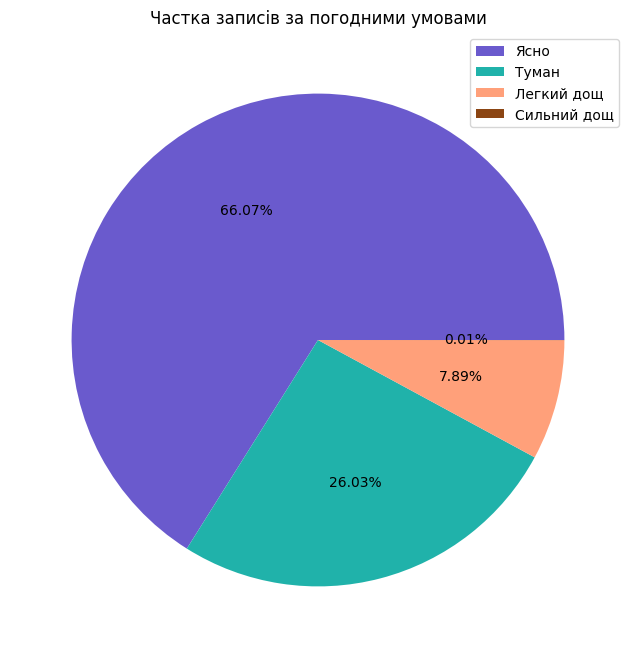

In [141]:
# з окремо винесеними легендами
weather_counts = df['weather'].value_counts().sort_index()

weather_counts.plot(
    kind='pie',
    autopct='%1.2f%%',
    labels=None,
    colors=['#6A5ACD', '#20B2AA', '#FFA07A', '#8B4513'],
    figsize=(8, 8),
    title='Частка записів за погодними умовами'
)

plt.ylabel('')

plt.legend([
    'Ясно',
    'Туман',
    'Легкий дощ',
    'Сильний дощ'
])

plt.show()

Якщо з підписами поряд із секторами:

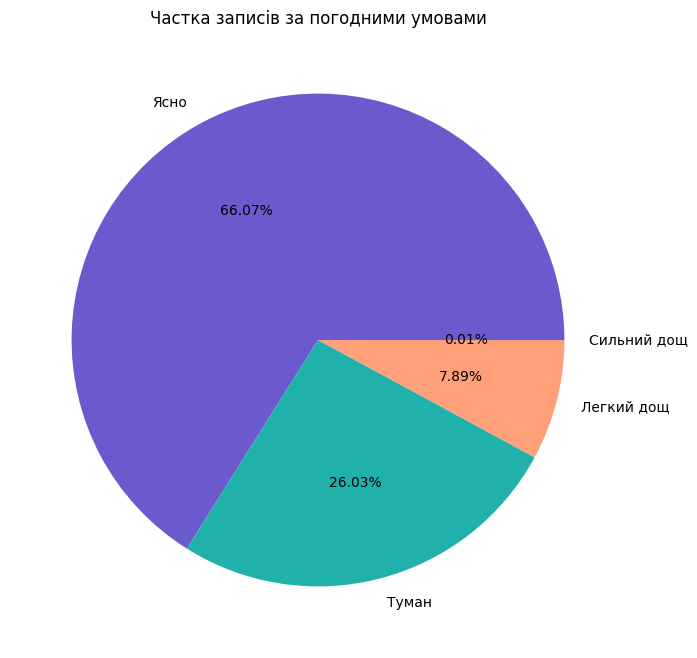

In [142]:
# з підписами поряд із секторами
weather_counts = df['weather'].value_counts().sort_index()

weather_counts.plot(
    kind='pie',
    autopct='%1.2f%%',
    labels=[
        'Ясно',
        'Туман',
        'Легкий дощ',
        'Сильний дощ'
    ],
    colors=['#6A5ACD', '#20B2AA', '#FFA07A', '#8B4513'],
    figsize=(8, 8),
    title='Частка записів за погодними умовами'
)

plt.ylabel('')
plt.show()

**Питання для інтерпретації:**
1. В датасеті переважає погода "Ясно".
2. Дні із сильним дощем є. Їх частка становить 0.01%.
3. Про вплив погодніх умов на попит на оренду велосипедів написала у попередньому завданні.

Очікуваний результат:

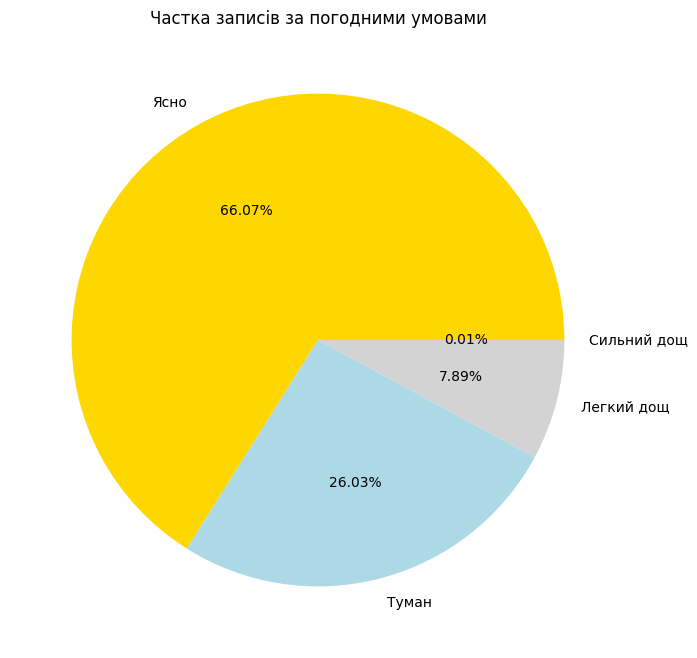

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

Для цього завдання ми будемо використовувати оригінальні погодинні дані, оскільки:

- **Погода фіксується погодинно, а не подобово**

Колонка `weather` у вихідному датасеті - це погодні умови в конкретну годину. Якщо ми зресемплимо дані, наприклад, до днів `(resample('D').sum())`, ми втратимо цю прив'язку: за один день погода могла бути і "ясно" вранці, і "дощ" ввечері. Тоді незрозуміло, яке значення `weather`призначити для агрегованого дня. Це вже неоднозначно і спотворить сенс аналізу.

Знайдемо, яке максимальне значення міститься у колонці `count` в оригінальних **погодинних** даних, а також короткий опис колонки `count`:

In [143]:
print(df['count'].max())
print(df['count'].describe())

977
count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64


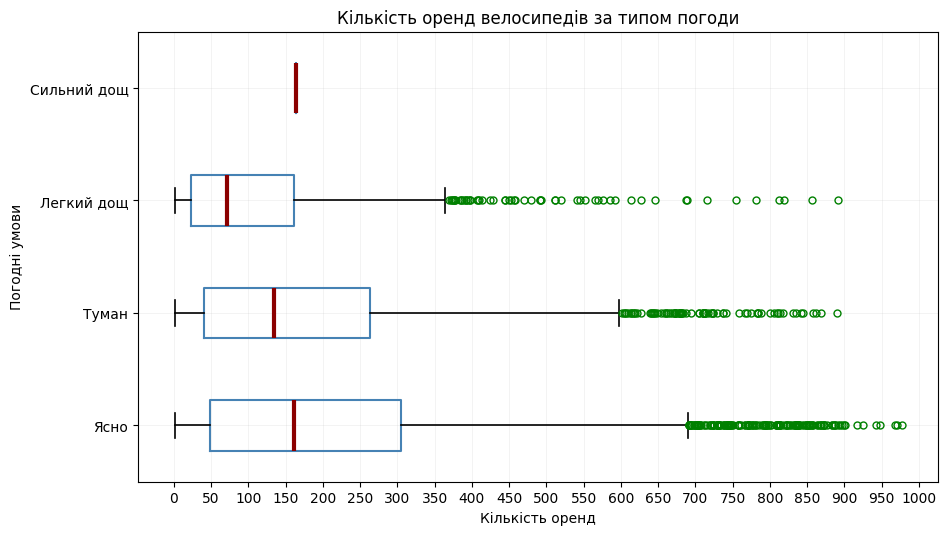

In [144]:
df.boxplot(
    column='count',
    by='weather',
    figsize=(10, 6),
    vert=False,
    boxprops=dict(color='steelblue', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    medianprops=dict(color='darkred', linewidth=3),
    flierprops=dict(markeredgecolor='green', markersize=5)
)

plt.title('Кількість оренд велосипедів за типом погоди')
plt.suptitle('')
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')

plt.yticks(
    [1, 2, 3, 4],
    ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
)

plt.xticks(np.arange(0, 1050, 50))  # позначки кожні 50 одиниць

plt.grid(True, alpha=0.2, linewidth=0.5)   # ледь помітна сітка

plt.show()

**Питання для інтерпретації:**

1. **При якій погоді найбільший розкид у кількості оренди?**

Найбільший розкид (за міжквартильним розмахом, IQR - шириною прямокутника) спостерігається при погоді "Ясно": box сягає приблизно від 50 до 300 оренд. Для порівняння, у "Тумані" box трохи вужчий (\~45-260), а в "Легкому дощі" - ще вужчий (\~25-160). Це логічно: коли погода хороша, попит на велосипеди коливається сильніше залежно від інших факторів (день тижня, час доби, сезон), тоді як у дощ попит стабільно низький незалежно від інших умов.

2. **Чи є викиди (outliers) в даних? При якій погоді?**

Викиди присутні і їх досить багато - у трьох з чотирьох категорій:

- "Ясно" - викиди розкидані від \~690 до \~950-980 оренд.
- "Туман" - також багато викидів, від ~600 до ~900.
- "Легкий дощ" - викиди від ~360 до ~900.
- "Сильний дощ" - викидів немає, але це радше через те, що спостережень для цієї категорії критично мало, тому статистично коректний box plot і поняття "викиду" там неможливо побудувати.

Щільність викидів (майже суцільна смуга кружечків) може свідчити, що це не поодинокі аномалії, а системний патерн - ймовірно, пов'язаний із сезонністю (пікові літні місяці чи вихідні з високим попитом незалежно від погоди).

3. **При якій погоді медіанне значення оренди найвище?**

Найвища медіана - при погоді "Ясно" (\~160 оренд). Далі йде "Туман" (\~135), потім "Легкий дощ" (\~70). Для "Сильного дощу" медіана становить приблизно 160, але через малу кількість спостережень це значення не варто порівнювати нарівні з іншими - це, по суті, одна точка даних, а не репрезентативна медіана розподілу.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

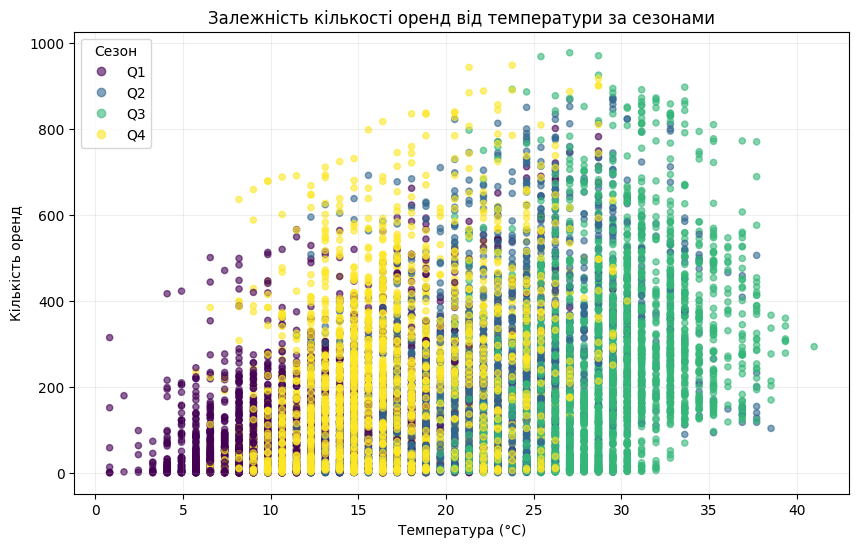

In [145]:
# будуємо з Pandas
df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    figsize=(10, 6),
    alpha=0.6,
    colorbar=False  # прибираємо теплову шкалу
)

# Легенда з назвами сезонів замість числових кодів
legend_labels = ['Q1', 'Q2', 'Q3', 'Q4']
handles, _ = scatter.legend_elements()
plt.legend(handles, legend_labels, title='Сезон', loc='upper left')

plt.title('Залежність кількості оренд від температури за сезонами')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')

plt.grid(True, alpha=0.2)
plt.show()

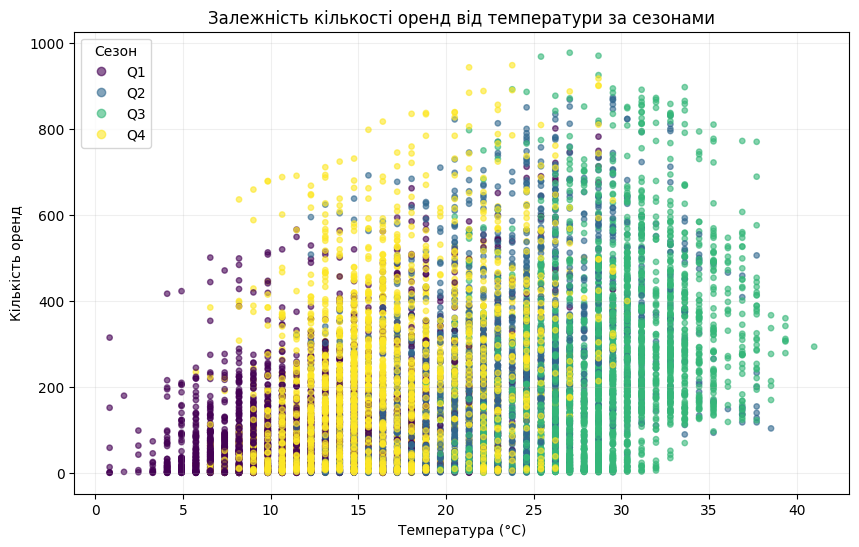

In [146]:
# будуємо з Matplotlib для порівняння з Pandas
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df['temp'],
    df['count'],
    c=df['season'],
    cmap='viridis',
    alpha=0.6,
    s=15
)

plt.title('Залежність кількості оренд від температури за сезонами')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')

# Легенда з назвами сезонів замість числових кодів
legend_labels = ['Q1', 'Q2', 'Q3', 'Q4']
handles, _ = scatter.legend_elements()
plt.legend(handles, legend_labels, title='Сезон', loc='upper left')

plt.grid(True, alpha=0.2)
plt.show()

**Питання для інтерпретації:** Чи є зв'язок між температурою та кількістю оренди? Який?

- **Нелінійна залежність**: кількість оренд зростає з температурою приблизно до `22-30°C`, а потім трохи спадає - люди менше катаються і в холод, і в спеку.
- **Сезони логічно розташовані по осі X**: Q1 (фіолетовий, зима) зосереджений зліва при низьких температурах, Q3 (зелений, літо) - справа при високих, Q2 і Q4 (весна/осінь) - посередині. Це підтверджує, що кодування кольорів працює коректно.
- **Найвищі значення** `count` (900-1000) зосереджені в діапазоні температур `22-30°C`, переважно влітку (Q3) та частково навесні/восени.
- **"Стовпчикова" структура точок**  виникає через дискретні значення `temp`: сусідні значення температури відрізняються переважно на `~0,82°C`. Тому точки лягають вертикальними смугами і розташовані на приблизно однаковій відстані одна від одної, а не суцільною хмарою.

In [147]:
temps = sorted(df['temp'].unique())
pd.Series(temps).diff().dropna().unique()

array([0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 1.64])

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

Подивимось на середню **ЩОГОДИННУ** і **ЩОДЕННУ** кількість оренд за днями тижня:

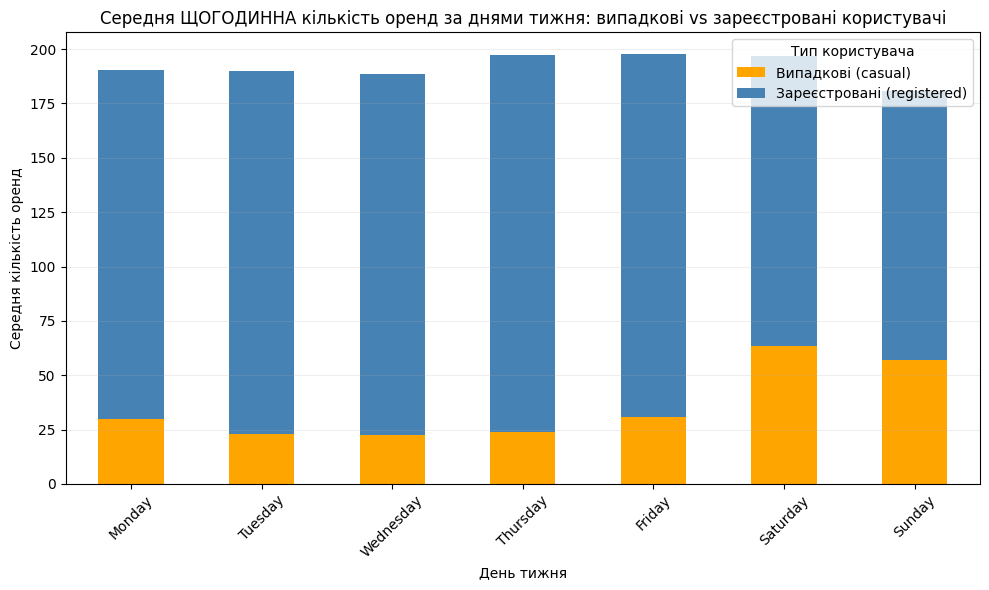

In [148]:
# Cередня ЩОГОДИННА кількість оренд за днями тижня

# Групуємо за днем тижня та рахуємо середні значення
weekday_avg = df.groupby(['weekday_num', 'weekday'])[['casual', 'registered']].mean()
weekday_avg = weekday_avg.reset_index().sort_values('weekday_num').set_index('weekday')

ax = weekday_avg[['casual', 'registered']].plot.bar(
    stacked=True,
    figsize=(10, 6),
    color=['orange', 'steelblue']
)

plt.title('Середня ЩОГОДИННА кількість оренд за днями тижня: випадкові vs зареєстровані користувачі')
plt.xlabel('День тижня')
plt.ylabel('Середня кількість оренд')
plt.xticks(rotation=45)
plt.legend(['Випадкові (casual)', 'Зареєстровані (registered)'], title='Тип користувача')
plt.grid(True, axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

In [149]:
print(df.groupby('weekday')['count'].agg(['mean', 'max']))

                 mean  max
weekday                   
Friday     197.844343  900
Monday     190.390716  968
Saturday   196.665404  783
Sunday     180.839772  757
Thursday   197.296201  901
Tuesday    189.723847  970
Wednesday  188.411348  977


In [150]:
# Скільки записів (годин) є для кожного дня тижня
print(df.groupby('weekday').size())

weekday
Friday       1529
Monday       1551
Saturday     1584
Sunday       1579
Thursday     1553
Tuesday      1539
Wednesday    1551
dtype: int64


In [151]:
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
missing_hours = full_range.difference(df.index)
print(f"Кількість пропущених годин: {len(missing_hours)}")

Кількість пропущених годин: 6370


In [152]:
total_hours = len(full_range)
print(f"Всього годин у діапазоні: {total_hours}")
print(f"Реально є записів: {len(df)}")
print(f"Пропущено: {len(missing_hours)} ({len(missing_hours)/total_hours*100:.1f}%)")

Всього годин у діапазоні: 17256
Реально є записів: 10886
Пропущено: 6370 (36.9%)


In [153]:
print(df['day'].max())
print(df['day'].value_counts().sort_index())

19
day
1     575
2     573
3     573
4     574
5     575
6     572
7     574
8     574
9     575
10    572
11    568
12    573
13    574
14    574
15    574
16    574
17    575
18    563
19    574
Name: count, dtype: int64


**Примітка щодо пропущених даних:**

Датасет містить записи лише за 1-19 число кожного місяця (дні 20-31 відсутні) —
це особливість оригінального датасету із Kaggle.

Наша перевірка показала, що кількість записів по днях тижня розподілена рівномірно
(1529-1584 записів на кожен день), тому це не впливає на коректність аналізу
"середня кількість оренд за днями тижня".

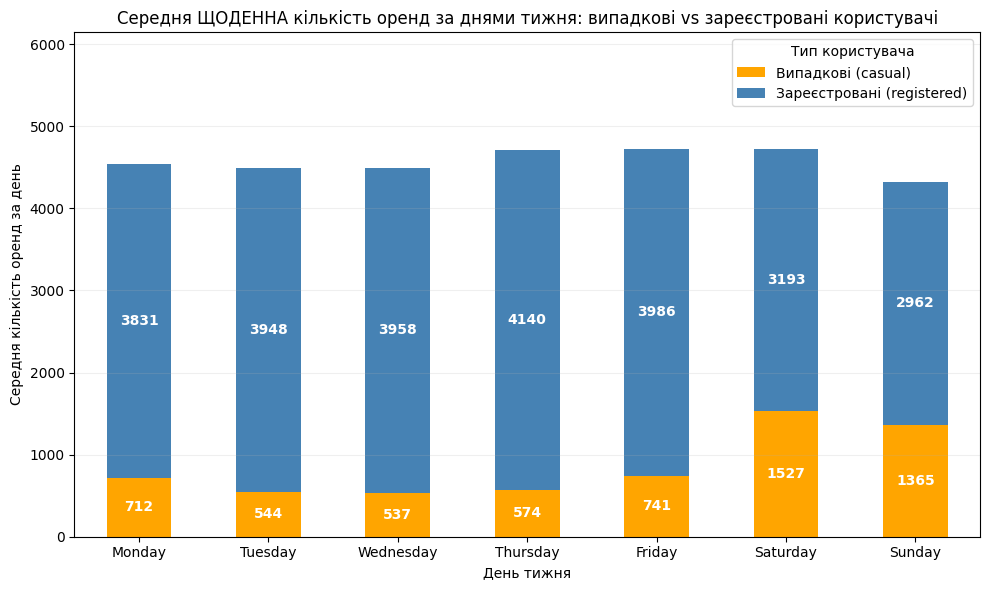

In [155]:
# Cередня ЩОДЕННА кількість оренд за днями тижня

# Крок 1: сума casual/registered за кожну конкретну дату
daily_totals = df.groupby(['date', 'weekday'])[['casual', 'registered']].sum().reset_index()

# Крок 2: середнє цих денних сум, згруповане за днем тижня
weekday_daily_avg = daily_totals.groupby('weekday')[['casual', 'registered']].mean()

# Правильний порядок днів тижня
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_daily_avg = weekday_daily_avg.reindex(weekday_order)

# Побудова графіка
ax = weekday_daily_avg.plot.bar(
    stacked=True,
    figsize=(10, 6),
    color=['orange', 'steelblue']
)

plt.title('Середня ЩОДЕННА кількість оренд за днями тижня: випадкові vs зареєстровані користувачі')
plt.xlabel('День тижня')
plt.ylabel('Середня кількість оренд за день')
plt.xticks(rotation=0)
plt.legend(['Випадкові (casual)', 'Зареєстровані (registered)'], title='Тип користувача')
plt.grid(True, axis='y', alpha=0.2)

# Підпис для кожного сегмента окремо (casual і registered)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='center', color='white', fontweight='bold')

# Додаємо відступ зверху графіка
max_total = weekday_daily_avg.sum(axis=1).max()
plt.ylim(0, max_total * 1.3)  # 15% запасу зверху

plt.tight_layout()
plt.show()

1. **В які дні тижня більше оренд від зареєстрованих користувачів?**

Найбільше оренд від зареєстрованих користувачів (синій сегмент) припадає на робочі дні, особливо четвер (4140) і п'ятниця (3986). У вихідні (субота - 3193, неділя - 2962) кількість оренд зареєстрованих користувачів помітно нижча - це мінімум за весь тиждень.

2. **Як пояснити таку різницю в поведінці користувачів протягом тижня?**

- **Зареєстровані користувачі** - це, найімовірніше, ті, хто оформив річну/довгострокову підписку на сервіс і використовує велосипед як регулярний транспорт для щоденних потреб: поїздки на роботу, навчання, по справах. Тому їхня активність висока саме в будні (пн-пт) і падає у вихідні, коли немає потреби їхати на роботу.
- **Випадкові користувачі (casual)** - навпаки, показують протилежну картину: у будні їх мало (537-741), а у вихідні кількість різко зростає (1365-1527, тобто майже вдвічі-втричі більше). Це логічно для людей, які орендують велосипед разово - туристів, для прогулянок, дозвілля, спонтанних поїздок у вільний час.

Цікаво, що загальна сума (casual + registered) залишається відносно стабільною по всіх днях (~4300-4700) - тобто загальний попит на велосипеди не сильно змінюється, змінюється лише склад користувачів.